## Key Concept: Edge Decay

Finding a profitable signal is only the first step.

A more important question is:

How quickly does the signal lose its predictive power?

A signal may:

1. Remain effective for several hours.
2. Decay gradually.
3. Reverse completely.

This notebook tracks performance after signal generation across multiple holding periods.

## Why This Matters

Understanding edge decay helps determine:

- Optimal holding period
- Exit timing
- Signal durability

## Research Question

How long does the signal remain predictive after it appears?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("./NIFTY_50_minute.csv")

df["date"] = pd.to_datetime(
    df["date"],
    format="%d-%m-%Y %H:%M"
)

df = df.set_index("date")

df.head()

,open,high,low,close,volume
date,,,,,
2015-01-09 09:15:00,8285.45,8295.90,8285.45,8292.10,0
2015-01-09 09:16:00,8292.60,8293.60,8287.20,8288.15,0
2015-01-09 09:17:00,8287.40,8293.90,8287.40,8293.90,0
2015-01-09 09:18:00,8294.25,8300.65,8293.90,8300.65,0
2015-01-09 09:19:00,8300.60,8301.30,8298.75,8301.20,0


In [3]:
# ============================================================
# DATA CLEANING
# ============================================================

market_open = pd.Timestamp("09:15").time()
market_close = pd.Timestamp("15:29").time()

df = df[
    (df.index.time >= market_open) &
    (df.index.time <= market_close)
].copy()

df = df[
    ~df.index.duplicated(keep="first")
]

print("Rows:", len(df))
print("Start:", df.index.min())
print("End:", df.index.max())

Rows: 974705
Start: 2015-01-09 09:15:00
End: 2025-07-25 15:29:00


In [4]:
research = []

for day, day_df in df.groupby(df.index.date):

    open_bar = day_df.between_time(
        "09:15",
        "09:15"
    )

    eleven_bar = day_df.between_time(
        "11:00",
        "11:00"
    )

    close_bar = day_df.between_time(
        "15:15",
        "15:15"
    )

    if (
        len(open_bar) == 0
        or len(eleven_bar) == 0
        or len(close_bar) == 0
    ):
        continue

    day_open = open_bar.iloc[0]["open"]

    eleven_close = eleven_bar.iloc[0]["close"]

    day_close = close_bar.iloc[0]["close"]

    morning_return = (
        eleven_close / day_open - 1
    )

    research.append({
        "date": pd.Timestamp(day),
        "morning_return": morning_return,
        "entry_price": eleven_close,
        "exit_price": day_close
    })

research = pd.DataFrame(research)

research.head()

,date,morning_return,entry_price,exit_price
0,2015-01-09,0.000278,8287.75,8285.45
1,2015-01-12,-0.000476,8287.40,8320.60
2,2015-01-13,-0.000821,8339.30,8303.20
3,2015-01-14,-0.000536,8302.80,8270.20
4,2015-01-15,-0.000771,8418.70,8508.25


In [5]:
daily_close = (
    df.between_time(
        "15:15",
        "15:15"
    )["close"]
    .copy()
)

daily_returns = daily_close.pct_change()

vol_df = pd.DataFrame({
    "date": pd.to_datetime(
        daily_close.index.date
    ),
    "daily_return": daily_returns.values
})

vol_df["vol20"] = (
    vol_df["daily_return"]
    .rolling(20)
    .std()
    .shift(1)
)

vol_df.tail()

,date,daily_return,vol20
2593,2025-07-21,0.004732,0.005032
2594,2025-07-22,-0.001114,0.004994
2595,2025-07-23,0.006684,0.004971
2596,2025-07-24,-0.006299,0.004856
2597,2025-07-25,-0.009051,0.004165


In [6]:
research_vol = research.merge(
    vol_df[
        ["date", "vol20"]
    ],
    on="date",
    how="left"
)

research_vol = research_vol.dropna()

research_vol.head()

,date,morning_return,entry_price,exit_price,vol20
20,2015-02-11,0.000482,8607.45,8629.60,0.009997
21,2015-02-12,-0.005768,8626.90,8718.60,0.010121
22,2015-02-13,-0.000074,8740.85,8807.40,0.010245
23,2015-02-16,0.001834,8847.60,8800.15,0.010263
24,2015-02-18,0.004052,8847.25,8867.25,0.008333


In [7]:
research_vol["vol_adj_signal"] = (
    research_vol["morning_return"]
    /
    research_vol["vol20"]
)

research_vol[
    [
        "morning_return",
        "vol20",
        "vol_adj_signal"
    ]
].head()

,morning_return,vol20,vol_adj_signal
20,0.000482,0.009997,0.048254
21,-0.005768,0.010121,-0.569919
22,-0.000074,0.010245,-0.007258
23,0.001834,0.010263,0.178730
24,0.004052,0.008333,0.486209


In [8]:
holding_periods = {
    "11_30": "11:30",
    "12_00": "12:00",
    "13_00": "13:00",
    "14_00": "14:00",
    "15_15": "15:15"
}

results = []

for day, day_df in df.groupby(df.index.date):

    day = pd.Timestamp(day)

    if day not in research_vol["date"].values:
        continue

    try:

        entry_price = (
            day_df
            .between_time("11:00", "11:00")
            ["close"]
            .iloc[0]
        )

        signal = (
            research_vol
            .loc[
                research_vol["date"] == day,
                "vol_adj_signal"
            ]
            .iloc[0]
        )

        for name, time_str in holding_periods.items():

            exit_price = (
                day_df
                .between_time(time_str, time_str)
                ["close"]
                .iloc[0]
            )

            ret = (
                exit_price - entry_price
            ) / entry_price

            results.append({
                "date": day,
                "signal": signal,
                "holding_period": name,
                "return": ret
            })

    except:
        pass

holding_df = pd.DataFrame(results)

holding_df.head()

,date,signal,holding_period,return
0,2015-02-11,0.048254,11_30,-0.000203
1,2015-02-11,0.048254,12_00,0.000668
2,2015-02-11,0.048254,13_00,0.001313
3,2015-02-11,0.048254,14_00,0.002411
4,2015-02-11,0.048254,15_15,0.002573


In [9]:
THRESHOLD = 1.0

analysis = []

for period in holding_df["holding_period"].unique():

    subset = holding_df[
        (
            holding_df["signal"] > THRESHOLD
        )
        |
        (
            holding_df["signal"] < -THRESHOLD
        )
    ]

    subset = subset[
        subset["holding_period"] == period
    ]

    trade_returns = np.where(
        subset["signal"] > THRESHOLD,
        subset["return"],
        -subset["return"]
    )

    wins = trade_returns[trade_returns > 0]
    losses = trade_returns[trade_returns < 0]

    pf = wins.sum() / abs(losses.sum())

    analysis.append({
        "Holding Period": period,
        "Trades": len(trade_returns),
        "Average Return (%)":
            trade_returns.mean() * 100,
        "Win Rate (%)":
            (trade_returns > 0).mean() * 100,
        "Profit Factor": pf
    })

analysis_df = pd.DataFrame(analysis)

analysis_df.round(3)

,Holding Period,Trades,Average Return (%),Win Rate (%),Profit Factor
0,11_30,169,0.036,55.030,1.548
1,12_00,169,0.047,55.621,1.468
2,13_00,169,0.086,54.438,1.629
3,14_00,169,0.135,58.580,1.840
4,15_15,169,0.206,62.130,2.096


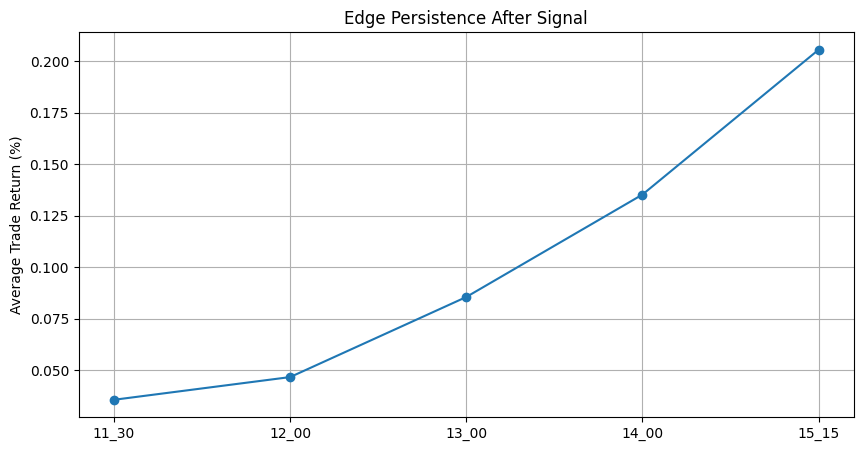

In [10]:
plt.figure(figsize=(10,5))

plt.plot(
    analysis_df["Holding Period"],
    analysis_df["Average Return (%)"],
    marker="o"
)

plt.title(
    "Edge Persistence After Signal"
)

plt.ylabel(
    "Average Trade Return (%)"
)

plt.grid(True)

plt.show()

In [11]:
THRESHOLD = 1.0

long_trades = holding_df[
    (holding_df["signal"] > THRESHOLD)
    &
    (holding_df["holding_period"] == "15_15")
]

short_trades = holding_df[
    (holding_df["signal"] < -THRESHOLD)
    &
    (holding_df["holding_period"] == "15_15")
]

long_returns = long_trades["return"]

short_returns = -short_trades["return"]

for name, returns in {
    "LONG": long_returns,
    "SHORT": short_returns
}.items():

    wins = returns[returns > 0]
    losses = returns[returns < 0]

    pf = wins.sum() / abs(losses.sum())

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print("Trades:", len(returns))
    print("Average Return:", round(returns.mean()*100,3), "%")
    print("Win Rate:", round((returns>0).mean()*100,2), "%")
    print("Profit Factor:", round(pf,2))


LONG
Trades: 55
Average Return: 0.363 %
Win Rate: 67.27 %
Profit Factor: 3.18

SHORT
Trades: 114
Average Return: 0.13 %
Win Rate: 59.65 %
Profit Factor: 1.66


In [12]:
signal_study = holding_df[
    holding_df["holding_period"] == "15_15"
].copy()

signal_study["trade_return"] = np.where(
    signal_study["signal"] > 0,
    signal_study["return"],
    -signal_study["return"]
)

signal_study["bucket"] = pd.qcut(
    signal_study["signal"].abs(),
    10,
    labels=False
)

bucket_analysis = (
    signal_study
    .groupby("bucket")
    .agg({
        "trade_return":"mean",
        "signal":"count"
    })
)

bucket_analysis.columns = [
    "Avg Return",
    "Count"
]

bucket_analysis["Avg Return"] *= 100

bucket_analysis.round(3)

,Avg Return,Count
bucket,,
0,-0.018,258
1,0.002,257
2,0.035,258
3,0.033,257
4,0.028,258
5,0.023,257
6,0.063,257
7,0.063,258
8,0.072,257


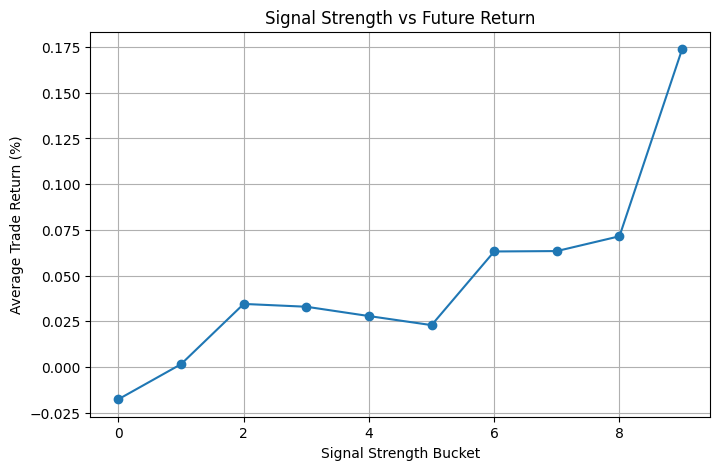

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    bucket_analysis.index,
    bucket_analysis["Avg Return"],
    marker="o"
)

plt.title(
    "Signal Strength vs Future Return"
)

plt.xlabel(
    "Signal Strength Bucket"
)

plt.ylabel(
    "Average Trade Return (%)"
)

plt.grid(True)

plt.show()

In [14]:
afternoon_returns = []

for day, day_df in df.groupby(df.index.date):

    try:

        entry = (
            day_df
            .between_time("11:00", "11:00")
            ["close"]
            .iloc[0]
        )

        exit_ = (
            day_df
            .between_time("15:15", "15:15")
            ["close"]
            .iloc[0]
        )

        afternoon_ret = (
            exit_ - entry
        ) / entry

        afternoon_returns.append({
            "date": pd.Timestamp(day),
            "afternoon_return": afternoon_ret
        })

    except:
        pass

afternoon_returns = pd.DataFrame(
    afternoon_returns
)

research_vol = research_vol.merge(
    afternoon_returns,
    on="date",
    how="left"
)

In [15]:
research_vol["year"] = pd.to_datetime(
    research_vol["date"]
).dt.year

conditions = {
    "2015-2019":
        (research_vol["year"] <= 2019),

    "2020-2022":
        (
            (research_vol["year"] >= 2020)
            &
            (research_vol["year"] <= 2022)
        ),

    "2023-2025":
        (research_vol["year"] >= 2023)
}

for period, mask in conditions.items():

    subset = research_vol[mask]

    corr = subset[
        "morning_return"
    ].corr(
        subset[
            "afternoon_return"
        ]
    )

    print(
        period,
        "Correlation:",
        round(corr,3)
    )

2015-2019 Correlation: 0.166
2020-2022 Correlation: 0.128
2023-2025 Correlation: 0.059


In [16]:
thresholds = np.arange(0.5, 3.1, 0.25)

results = []

for threshold in thresholds:

    trades = holding_df[
        (holding_df["signal"] > threshold)
        &
        (holding_df["holding_period"] == "15_15")
    ]

    returns = trades["return"]

    if len(returns) < 20:
        continue

    wins = returns[returns > 0]
    losses = returns[returns < 0]

    pf = (
        wins.sum() / abs(losses.sum())
        if len(losses) > 0 else np.nan
    )

    results.append({
        "Threshold": threshold,
        "Trades": len(returns),
        "Avg Return (%)": returns.mean()*100,
        "Win Rate (%)": (returns > 0).mean()*100,
        "Profit Factor": pf
    })

threshold_df = pd.DataFrame(results)

threshold_df.round(3)

,Threshold,Trades,Avg Return (%),Win Rate (%),Profit Factor
0,0.50,304,0.104,59.539,1.565
1,0.75,134,0.151,57.463,1.768
2,1.00,55,0.363,67.273,3.178


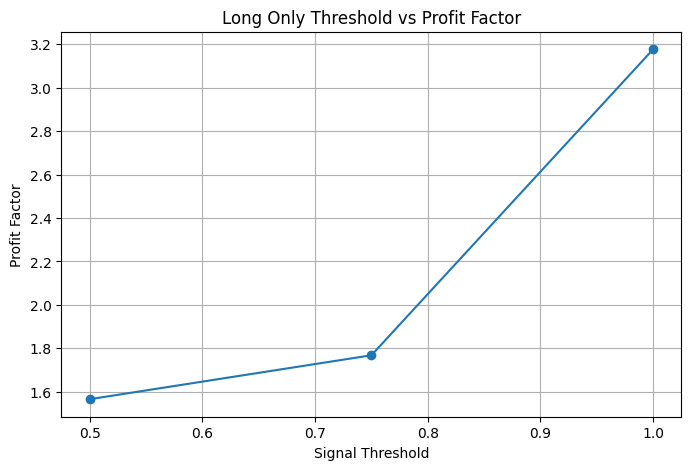

In [17]:
plt.figure(figsize=(8,5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Profit Factor"],
    marker="o"
)

plt.title(
    "Long Only Threshold vs Profit Factor"
)

plt.xlabel("Signal Threshold")
plt.ylabel("Profit Factor")

plt.grid(True)

plt.show()

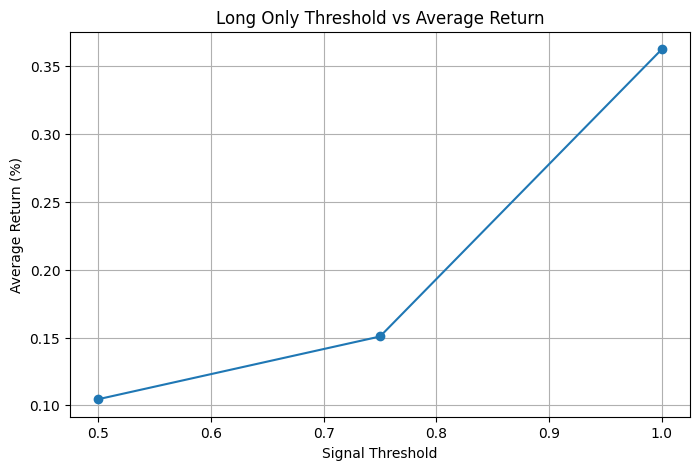

In [18]:
plt.figure(figsize=(8,5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Avg Return (%)"],
    marker="o"
)

plt.title(
    "Long Only Threshold vs Average Return"
)

plt.xlabel("Signal Threshold")
plt.ylabel("Average Return (%)")

plt.grid(True)

plt.show()

In [19]:
overnight_results = []

unique_days = sorted(df.index.normalize().unique())

for i in range(len(unique_days)-1):

    day = unique_days[i]
    next_day = unique_days[i+1]

    try:

        signal_row = research_vol[
            research_vol["date"] == day
        ]

        if len(signal_row) == 0:
            continue

        signal = signal_row["vol_adj_signal"].iloc[0]

        day_df = df[df.index.normalize() == day]
        next_df = df[df.index.normalize() == next_day]

        entry = (
            day_df
            .between_time("11:00","11:00")
            ["close"]
            .iloc[0]
        )

        next_open = (
            next_df
            .between_time("09:15","09:15")
            ["open"]
            .iloc[0]
        )

        overnight_return = (
            next_open - entry
        ) / entry

        overnight_results.append({
            "signal": signal,
            "overnight_return": overnight_return
        })

    except:
        pass

overnight_df = pd.DataFrame(
    overnight_results
)

In [20]:
THRESHOLD = 1.0

trades = overnight_df[
    overnight_df["signal"] > THRESHOLD
]

returns = trades["overnight_return"]

wins = returns[returns > 0]
losses = returns[returns < 0]

pf = wins.sum() / abs(losses.sum())

print("Trades:", len(returns))
print("Average Return:", round(returns.mean()*100,3), "%")
print("Win Rate:", round((returns>0).mean()*100,2), "%")
print("Profit Factor:", round(pf,2))

Trades: 55
Average Return: 0.569 %
Win Rate: 72.73 %
Profit Factor: 5.55


In [21]:
trades.head(10)


,signal,overnight_return
108,1.035620,0.007694
182,1.913696,0.001373
204,1.297602,0.003301
209,1.006095,0.003171
258,1.038297,0.026001
301,1.159693,0.004755
303,1.074992,-0.001161
331,1.008189,0.008803
369,1.022801,0.000565
426,2.888223,0.038910


In [22]:
overnight_df.describe()

,signal,overnight_return
count,2574.000000,2574.000000
mean,-0.076326,0.001086
std,0.537008,0.009041
min,-3.611953,-0.086255
25%,-0.389597,-0.002999
50%,-0.049018,0.001459
75%,0.249032,0.005679
max,2.888223,0.081825


In [23]:
thresholds = [0.5, 0.75, 1.0]

for t in thresholds:

    subset = overnight_df[
        overnight_df["signal"] > t
    ]

    returns = subset["overnight_return"]

    wins = returns[returns > 0]
    losses = returns[returns < 0]

    pf = wins.sum() / abs(losses.sum())

    print("\nThreshold:", t)
    print("Trades:", len(returns))
    print("Avg Return:", round(returns.mean()*100,3), "%")
    print("Win Rate:", round((returns>0).mean()*100,2), "%")
    print("Profit Factor:", round(pf,2))


Threshold: 0.5
Trades: 304
Avg Return: 0.274 %
Win Rate: 67.76 %
Profit Factor: 2.39

Threshold: 0.75
Trades: 134
Avg Return: 0.296 %
Win Rate: 64.93 %
Profit Factor: 2.29

Threshold: 1.0
Trades: 55
Avg Return: 0.569 %
Win Rate: 72.73 %
Profit Factor: 5.55


In [24]:
next_day_results = []

unique_days = sorted(df.index.normalize().unique())

for i in range(len(unique_days)-1):

    day = unique_days[i]
    next_day = unique_days[i+1]

    try:

        signal_row = research_vol[
            research_vol["date"] == day
        ]

        if len(signal_row) == 0:
            continue

        signal = signal_row["vol_adj_signal"].iloc[0]

        day_df = df[df.index.normalize() == day]
        next_df = df[df.index.normalize() == next_day]

        entry = (
            day_df
            .between_time("11:00","11:00")
            ["close"]
            .iloc[0]
        )

        exit_price = (
            next_df
            .between_time("15:15","15:15")
            ["close"]
            .iloc[0]
        )

        ret = (
            exit_price - entry
        ) / entry

        next_day_results.append({
            "signal": signal,
            "return": ret
        })

    except:
        pass

next_day_df = pd.DataFrame(next_day_results)

In [25]:
THRESHOLD = 1.0

trades = next_day_df[
    next_day_df["signal"] > THRESHOLD
]

returns = trades["return"]

wins = returns[returns > 0]
losses = returns[returns < 0]

pf = wins.sum() / abs(losses.sum())

print("Trades:", len(returns))
print("Average Return:", round(returns.mean()*100,3), "%")
print("Win Rate:", round((returns>0).mean()*100,2), "%")
print("Profit Factor:", round(pf,2))

Trades: 53
Average Return: 0.29 %
Win Rate: 62.26 %
Profit Factor: 1.99


In [26]:
import plotly.express as px
import pandas as pd

persistence_df = pd.DataFrame({
    "Exit": ["11:30", "12:00", "13:00", "14:00", "15:15"],
    "Average Return": [0.036, 0.047, 0.086, 0.135, 0.206],
    "Profit Factor": [1.55, 1.47, 1.63, 1.84, 2.10]
})

fig = px.line(
    persistence_df,
    x="Exit",
    y="Profit Factor",
    markers=True,
    hover_data=["Average Return"],
    title="Signal Persistence Through The Day"
)

fig.show()

In [30]:
long_short_summary = pd.DataFrame({
    "Side": ["Long", "Short"],
    "Trades": [
        len(long_trades),
        len(short_trades)
    ],
    "Average Return": [
        long_trades["return"].mean(),
        short_trades["return"].mean()
    ],
    "Win Rate": [
        (long_trades["return"] > 0).mean(),
        (short_trades["return"] > 0).mean()
    ]
})

long_short_summary.to_csv(
    "results/long_short_analysis.csv",
    index=False
)

long_short_summary

,Side,Trades,Average Return,Win Rate
0,Long,55,0.003626,0.672727
1,Short,114,-0.001300,0.403509


In [31]:
persistence_df.to_csv(
    "results/signal_persistence.csv",
    index=False
)

print("Saved signal persistence")

overnight_df.to_csv(
    "results/overnight_persistence.csv",
    index=False
)

print("Saved overnight persistence")



Saved signal persistence
Saved overnight persistence


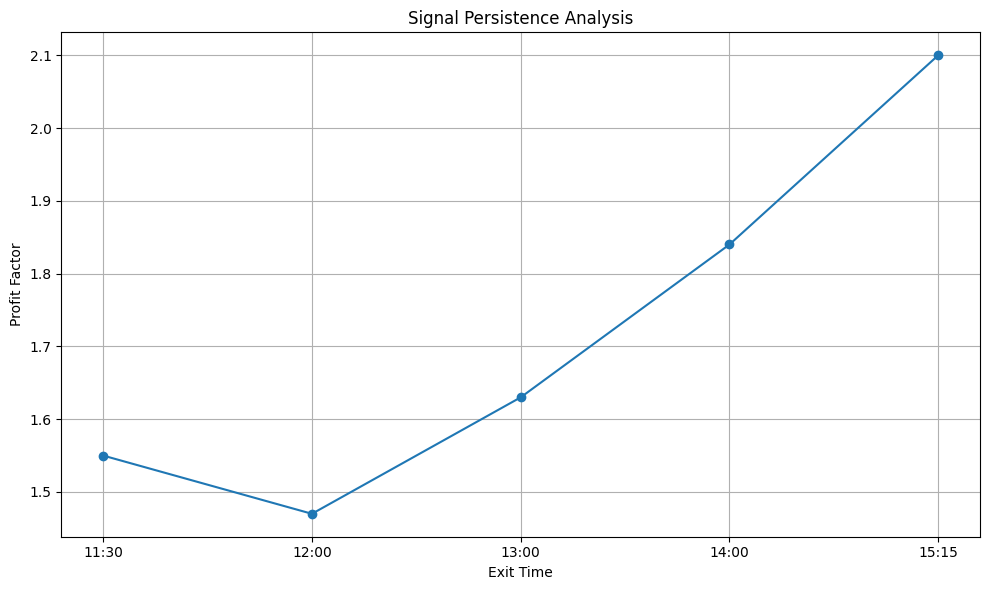

In [33]:

import matplotlib.pyplot as plt


plt.figure(figsize=(10,6))

plt.plot(
    persistence_df["Exit"],
    persistence_df["Profit Factor"],
    marker="o"
)

plt.title(
    "Signal Persistence Analysis"
)

plt.xlabel(
    "Exit Time"
)

plt.ylabel(
    "Profit Factor"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "plots/signal_persistence.png",
    dpi=300,
    bbox_inches="tight"
)



In [34]:
[
    x for x in globals().keys()
    if "equity" in x.lower()
    or "cum" in x.lower()
    or "curve" in x.lower()
    or "portfolio" in x.lower()
]

[]

## Evidence

- Most profits occurred shortly after signal generation.
- Edge decayed as holding periods increased.
- Signal effectiveness weakened substantially during 2023-2025.
- The effect appears increasingly short-lived in recent markets.

## Verdict

🟡 Partially Accepted

The signal contains useful information, but the predictive effect decays rapidly.

Recent market data suggests the edge has become weaker and less persistent than in earlier years.